ДР 8. Группа 10. Байес. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Проверочные задания по классификации текста

### На входе у Вас будет набор текстовых отзывов о фильмах, размеченных как положительные и отрицательные (позитивные и негативные).

Более подробно об этих данных можно почитать здесь: http://ai.stanford.edu/~amaas/data/sentiment/

## Выполните задания, написанные жирным шрифтом!

**Задание: Выполните импорт библиотек и загрузите данные из файла в датафрейм pandas.** <br>
Данные для этого задания находятся в файле `'../DATA/moviereviews.csv'`.

In [1]:
# Напишите Ваш код в этой ячейке
import pandas as pd
import numpy as np


In [24]:
df = pd.read_csv ('moviereviews.csv', index_col=0)

df.head()

,label,review
index,,
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


**Задание: Проверьте, есть ли какие-либо отсутствующие значения в этих данных.**

In [25]:
# Напишите Ваш код в этой ячейке
df.isnull().sum()

label      0
review    35
dtype: int64

**Задание: Удалите отзывы о фильмах, текст которых принимает значение NaN**

In [26]:
df = df.dropna()

df.isnull().sum()

label     0
review    0
dtype: int64

**Задание: Проверьте, есть ли какие-то отзывы с пустым текстом, но отличающимся от значения NaN. То есть, текст может быть таким: "" или "  " или какая-то другая строка из нескольких пробелов. Как это можно проверить? Это можно сделать разными способами. После того как Вы найдёте такие отзывы, удалите их из датафрейма. [В качестве подсказки можете использовать эту ссылку.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.isspace.html)**

In [27]:
empty_reviews = df[df['review'].str.strip() == '']

empty_reviews

,label,review
index,,
57,neg,
71,pos,
147,pos,
151,pos,
283,pos,
307,pos,
313,neg,
323,pos,
343,pos,


In [28]:
df = df[df['review'].str.strip() != '']

In [29]:
df.shape

(1938, 2)

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 1938 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   1938 non-null   str  
 1   review  1938 non-null   str  
dtypes: str(2)
memory usage: 45.4 KB


**Задание: Посчитайте количество строк для различных значений колонки label:**

In [31]:
# Напишите Ваш код в этой ячейке
df['label'].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

## Исследование данных (EDA) для мешка слов (bag of words)

**Бонусное задание: можете ли Вы с помощью модели CountVectorizer найти 20 наиболее часто встречающихся слов (которые не являются стоп-словами в английском языке), отдельно для каждого значения колонки label? Обратите внимание, что это бонусное задание, и здесь Вам нужно будет сделать нечто такое, что мы не проходили в лекциях. Однако мы надеемся, что с помощью поиска в Google или другом поисковике Вы сможете найти недостающие элементы.  [В качестве подсказки можете использовать эту ссылку.](https://stackoverflow.com/questions/16288497/find-the-most-common-term-in-scikit-learn-classifier)**

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

In [33]:
cv = CountVectorizer(stop_words='english')

neg_matrix = cv.fit_transform(df[df['label'] == 'neg']['review'])

neg_counts = neg_matrix.sum(axis=0).A1

neg_words = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': neg_counts
})

neg_words.sort_values(by='count', ascending=False).head(20)

,word,count
9136,film,4063
16000,movie,3131
14210,like,1808
13318,just,1480
24753,time,1127
10395,good,1117
2004,bad,997
4099,character,926
23426,story,908
18292,plot,888


In [34]:
cv = CountVectorizer(stop_words='english')

pos_matrix = cv.fit_transform(df[df['label'] == 'pos']['review'])

pos_counts = pos_matrix.sum(axis=0).A1

pos_words = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': pos_counts
})

pos_words.sort_values(by='count', ascending=False).head(20)

,word,count
9925,film,5002
17200,movie,2389
15273,like,1721
14347,just,1273
25091,story,1199
11272,good,1193
26494,time,1175
4421,character,1037
15231,life,1032
4431,characters,957


### Данные и обучение модели

**Задание: Разделите данные на признаки X и целевую переменную y, а также выполните разбиение на обучающий и тестовый наборы данных (train/test split). Вы можете использовать любые значения параметров, но если Вы захотите свериться с блокнотом с решениями, то в нём мы использовали `test_size=0.20, random_state=101`**

In [35]:
# Напишите Ваш код в этой ячейке
from sklearn.model_selection import train_test_split

In [36]:
X = df['review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=101
)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1550,)
(388,)
(1550,)
(388,)


### Обучение модели

**Задание: Создайте пайплайн, в котором Вы создадите вектора TF-IDF из сырых текстовых даных, а затем обучите модель машинного обучения, которую сами выберете. После создания пайплайна выполните его обучение на обучающем наборе данных.**

In [38]:
# Напишите Ваш код в этой ячейке
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

In [39]:
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

text_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


**Задание: выведите на экран отчёт "classification report" и матрицу ошибок для результатов работы пайплайна на тестовых данных.**

In [40]:
# Напишите Ваш код в этой ячейке
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [41]:
predictions = text_clf.predict(X_test)

In [42]:
cm = confusion_matrix(y_test, predictions, labels=['neg', 'pos'])

In [43]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[164  27]
 [ 38 159]]


In [44]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

         neg       0.81      0.86      0.83       191
         pos       0.85      0.81      0.83       197

    accuracy                           0.83       388
   macro avg       0.83      0.83      0.83       388
weighted avg       0.83      0.83      0.83       388



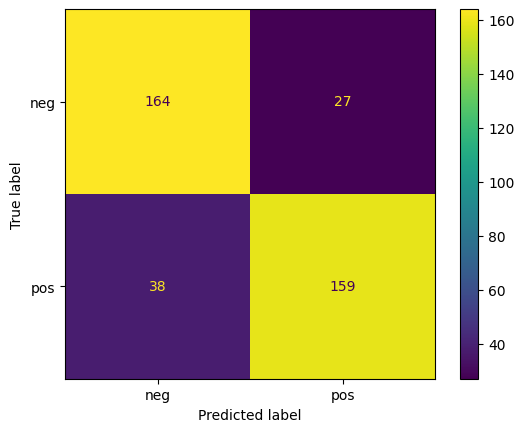

In [45]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['neg', 'pos']
)

disp.plot()
plt.show()

## Отличная работа!